In [ ]:
from PIL import Image
from os.path import join
import sys
import cv2
import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, '..')
from config import TIFFS_DIR

In [ ]:
base_dir = str(TIFFS_DIR / "1M02" / "1M02_Wholeslide_Default_Extended_tiles_100x100")

In [8]:
tile_relative_path = r"1M02_Wholeslide_Default_Extended_tile_50_60.png"

In [9]:
pil_im = Image.open(join(base_dir, tile_relative_path), 'r')

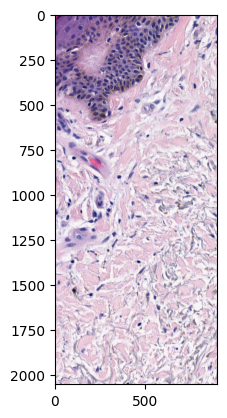

In [10]:
plt.imshow(pil_im)

In [18]:
tile_array = np.asarray(pil_im)

In [19]:
gray = cv2.cvtColor(tile_array, cv2.COLOR_RGB2GRAY)

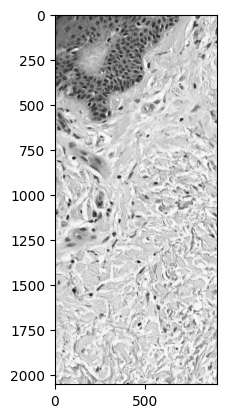

In [21]:
plt.imshow(gray, cmap = 'gray')

In [22]:
# Background pixels will be very bright
signal_mask = gray < 240

In [23]:
signal_fraction = np.sum(signal_mask) / signal_mask.size

In [24]:
signal_fraction

0.8863053607697893

In [25]:
tissue_threshold=0.1
signal_fraction < tissue_threshold

False

In [26]:
# Divide image into quadrants and check signal distribution
h, w = signal_mask.shape
quadrants = [
    signal_mask[:h // 2, :w // 2],  # top-left
    signal_mask[:h // 2, w // 2:],  # top-right
    signal_mask[h // 2:, :w // 2],  # bottom-left
    signal_mask[h // 2:, w // 2:]  # bottom-right
]

In [29]:
quadrant_fractions = [np.sum(q) / q.size for q in quadrants]

In [30]:
quadrant_fractions

[0.9615962746372103, 0.9112347263823516, 0.8653056366980417, 0.807302607858335]

In [31]:
max_quadrant = max(quadrant_fractions)

In [32]:
max_quadrant

0.9615962746372103

In [33]:
signal_concentration = max_quadrant / (signal_fraction + 1e-6)

In [34]:
signal_concentration

1.0849479561469344

In [ ]:
def is_tissue_tile(tile_array, tissue_threshold=0.1, concentration_threshold=0.7):
    """
    Check if a tile contains sufficient tissue content considering spatial distribution.

    Args:
        tile_array: numpy array of RGB image (H&E stained)
        tissue_threshold: minimum fraction of non-background pixels required
        concentration_threshold: how concentrated the signal should be in the non-empty part
    """
    # Convert to grayscale
    gray = cv2.cvtColor(tile_array, cv2.COLOR_RGB2GRAY)

    # Background pixels will be very bright
    signal_mask = gray < 240

    # Calculate total signal fraction
    signal_fraction = np.sum(signal_mask) / signal_mask.size

    if signal_fraction < tissue_threshold:
        return False

    # Divide image into quadrants and check signal distribution
    h, w = signal_mask.shape
    quadrants = [
        signal_mask[:h // 2, :w // 2],  # top-left
        signal_mask[:h // 2, w // 2:],  # top-right
        signal_mask[h // 2:, :w // 2],  # bottom-left
        signal_mask[h // 2:, w // 2:]  # bottom-right
    ]

    # Calculate signal fraction in each quadrant
    quadrant_fractions = [np.sum(q) / q.size for q in quadrants]

    # If signal is concentrated (high fraction in some quadrants, low in others)
    # this suggests it's a border tile
    max_quadrant = max(quadrant_fractions)
    signal_concentration = max_quadrant / (signal_fraction + 1e-6)  # avoid div by 0

    return signal_concentration >= concentration_threshold